In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

BINARY_PFS = True
RNA_SEQ_ONLY = True

pfs_dir = "binary" if BINARY_PFS else "three-classes"
rna_suffix = "_rna" if RNA_SEQ_ONLY else ""

x_train = pd.read_csv(f"../dataset/created/{pfs_dir}/x_train{rna_suffix}.csv")
x_test  = pd.read_csv(f"../dataset/created/{pfs_dir}/x_test{rna_suffix}.csv")
y_train = pd.read_csv(f"../dataset/created/{pfs_dir}/y_train{rna_suffix}.csv").squeeze()
y_test  = pd.read_csv(f"../dataset/created/{pfs_dir}/y_test{rna_suffix}.csv").squeeze()

x = pd.concat([x_train, x_test], ignore_index=True)
y = pd.concat([y_train, y_test], ignore_index=True)

print(f"Dataset: {x.shape[0]} samples, {x.shape[1]} features")
print(f"Target distribution: {y.value_counts().to_dict()}")

Dataset: 78 samples, 34 features
Target distribution: {0: 47, 1: 31}


## Encode features

In [14]:
x_enc = x.copy()

# Drop zero-variance columns
constant_cols = [c for c in x_enc.columns if x_enc[c].nunique() <= 1]
if constant_cols:
    print(f"Dropping constant columns: {constant_cols}")
    x_enc.drop(columns=constant_cols, inplace=True)

# Ordinal / binary encoding for categorical columns
cat_maps = {
    "M_stage":    {"M1A": 0, "M1B": 1, "M1C": 2},
    "sex":        {"female": 0, "male": 1},
    "AJCC_stage": {"IIIC": 0, "IV": 1},
    "LDH":        {"normal": 0, "elevated": 1},
}

for col, mapping in cat_maps.items():
    if col in x_enc.columns:
        x_enc[col] = x_enc[col].map(mapping)

print("Encoded dtypes:")
print(x_enc.dtypes)

Dropping constant columns: ['immunotherapy_treatment', 'pre_MAPKi_treatment']
Encoded dtypes:
M_stage        float64
sex              int64
AJCC_stage       int64
LDH            float64
age              int64
cobimetinib      int64
trametinib       int64
dabrafenib       int64
vemurafenib      int64
MND              int64
V600E            int64
V600K            int64
ADAM9          float64
ALDH5A1        float64
CLN8           float64
CXCR5          float64
DOCK1          float64
FANCC          float64
LATS2          float64
MIR23B         float64
NME7           float64
NOTCH1         float64
PGM3           float64
POU5F1B        float64
PTPDC1         float64
PYROXD2        float64
REEP4          float64
SLC25A26       float64
SLC36A1        float64
STX2           float64
TBC1D1         float64
TTYH3          float64
dtype: object


## Correlation Analysis

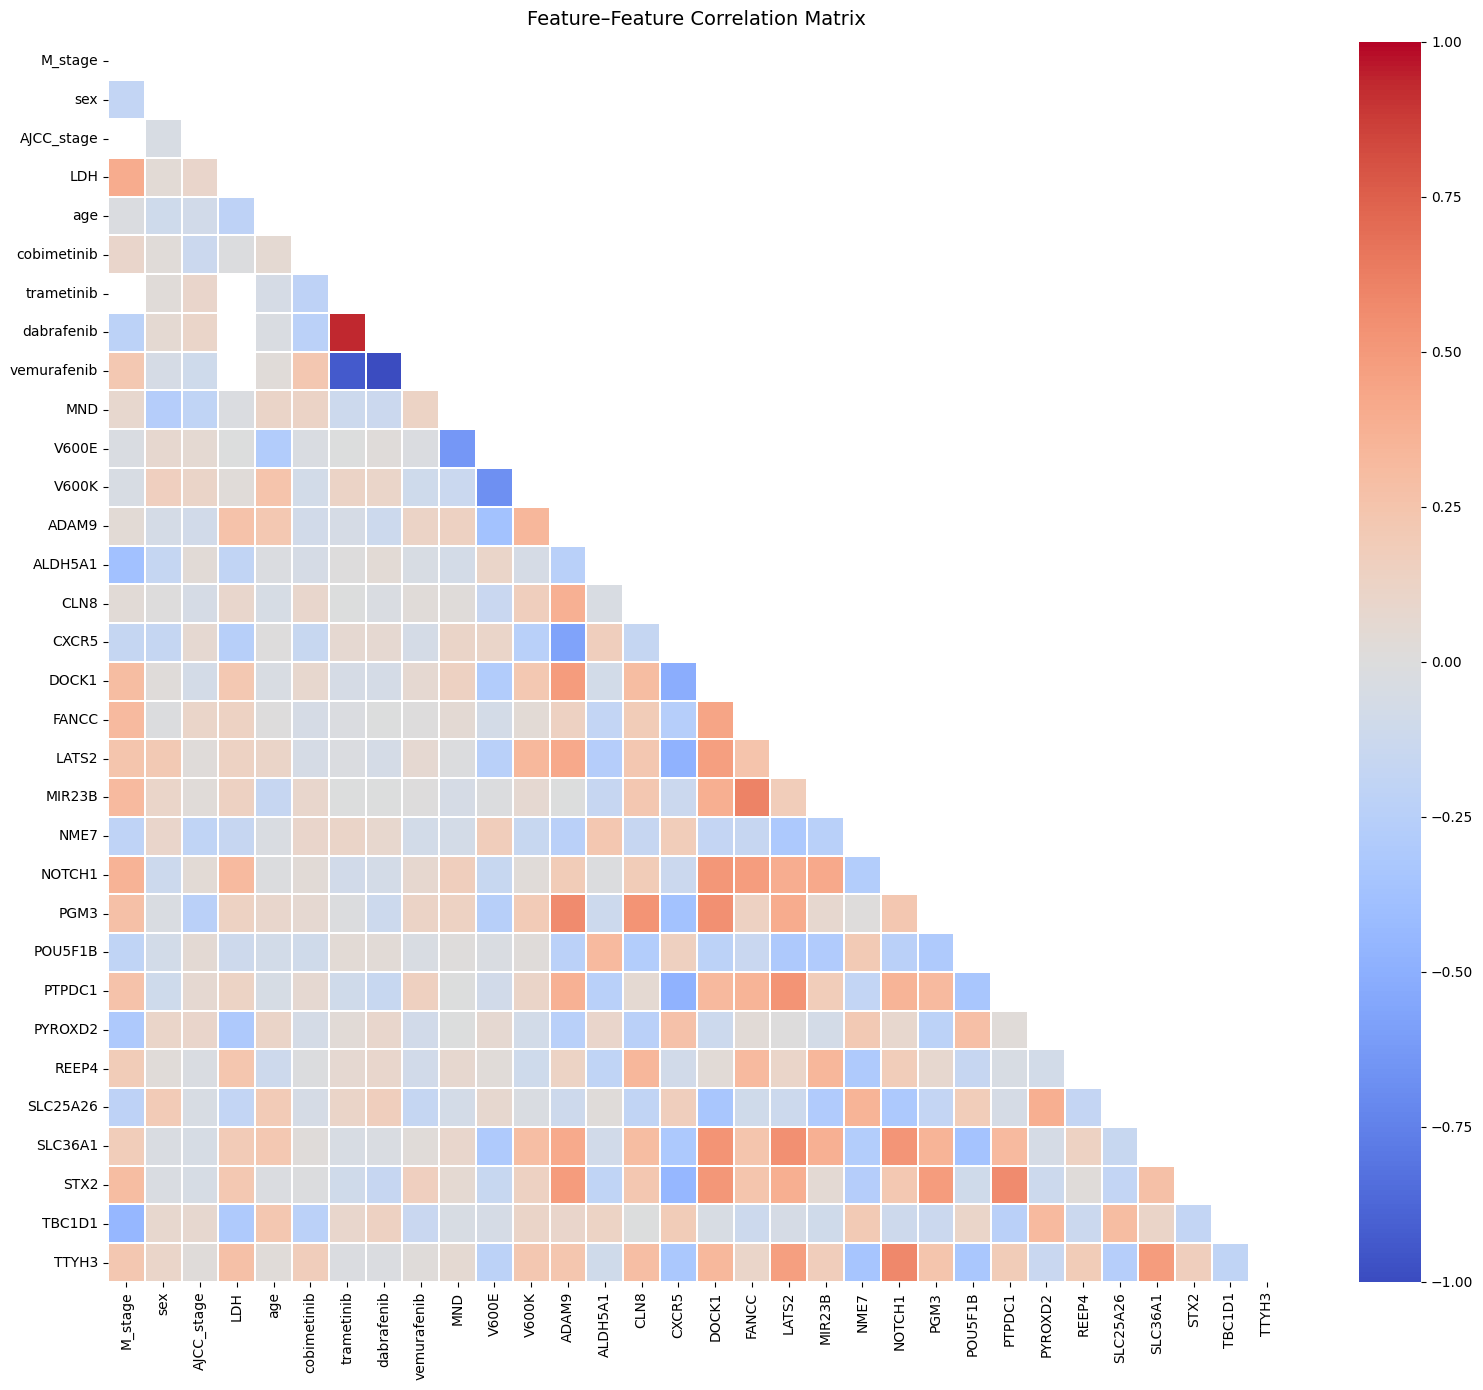

In [15]:
corr_matrix = x_enc.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax,
)
ax.set_title("Feature–Feature Correlation Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

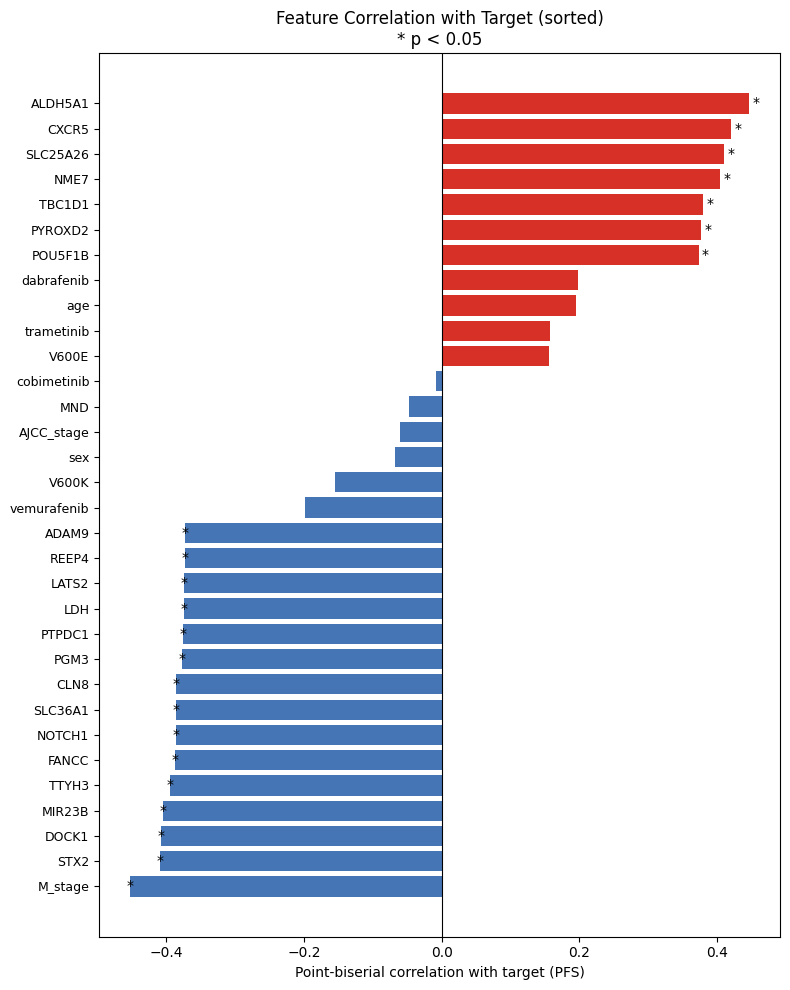

,correlation,p_value
M_stage,-0.452523,0.000032
STX2,-0.408468,0.000205
DOCK1,-0.407228,0.000215
MIR23B,-0.404964,0.000235
TTYH3,-0.394939,0.000346
FANCC,-0.387726,0.000453
NOTCH1,-0.386145,0.000480
SLC36A1,-0.385889,0.000484
CLN8,-0.385385,0.000493
PGM3,-0.376698,0.000676


In [16]:
corr_with_target = x_enc.apply(lambda col: stats.pointbiserialr(col.fillna(col.median()), y)[0])
pval_with_target  = x_enc.apply(lambda col: stats.pointbiserialr(col.fillna(col.median()), y)[1])

corr_df = pd.DataFrame({
    "correlation": corr_with_target,
    "p_value":     pval_with_target,
}).sort_values("correlation")

colors = corr_df["correlation"].apply(lambda v: "#d73027" if v > 0 else "#4575b4")
sig     = corr_df["p_value"] < 0.05

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(corr_df.index, corr_df["correlation"], color=colors, edgecolor="none")

for bar, is_sig in zip(bars, sig):
    if is_sig:
        ax.text(
            bar.get_width() + 0.005 * np.sign(bar.get_width() + 1e-9),
            bar.get_y() + bar.get_height() / 2,
            "*", va="center", ha="left", fontsize=10, color="black",
        )

ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Point-biserial correlation with target (PFS)")
ax.set_title("Feature Correlation with Target (sorted)\n* p < 0.05", fontsize=12)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

corr_df

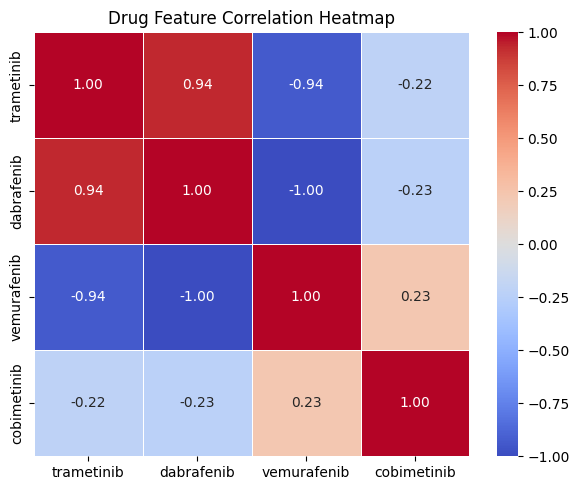

In [17]:
drugs = ["trametinib", "dabrafenib", "vemurafenib", "cobimetinib"]
drug_corr = x_enc[drugs].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    drug_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Drug Feature Correlation Heatmap", fontsize=12)
plt.tight_layout()
plt.show()